# 4. Modélisation supervisée et semi-supervisée

Objectif : comparer un modèle entraîné uniquement sur les données fortement labellisées avec un modèle semi-supervisé utilisant aussi des pseudo-labels issus du clustering.

On va comparer :
- Modèle supervisé baseline = entraîné uniquement sur les 100 images fortement labellisées
- Modèle semi-supervisé = entraîné sur les labels forts + pseudo-labels issus du clustering KMeans

Et surtout : le test set doit venir uniquement des labels forts, jamais des pseudo-labels.

Le split fort est 50/50 :
- 50 images fortement labellisées pour l'entraînement supervisé ;
- 50 images fortement labellisées pour le test final commun aux deux approches.

Les pseudo-labels ne sont attribués qu'aux images `unknown`. Les labels réels `normal` et `cancer` restent prioritaires.

In [41]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [42]:
# Charger les résultats de clustering
DATA_PATH = Path("data/processed/clustering_results.csv")

df = pd.read_csv(DATA_PATH)

feature_columns = [col for col in df.columns if col.startswith("feature_")]

print("Shape :", df.shape)
print("Nombre de features :", len(feature_columns))
display(df["label"].value_counts())

Shape : (1506, 525)
Nombre de features : 512


label
unknown    1406
cancer       50
normal       50
Name: count, dtype: int64

In [43]:
# Séparation labels forts / unknown
strong_df = df[df["label"].isin(["normal", "cancer"])].copy()
unknown_df = df[df["label"] == "unknown"].copy()

print("Labels forts :", strong_df.shape)
display(strong_df["label"].value_counts())

print("Unknown :", unknown_df.shape)

Labels forts : (100, 525)


label
cancer    50
normal    50
Name: count, dtype: int64

Unknown : (1406, 525)


In [24]:
# Séparer données fortes et unknown
strong_df = df[df["label"].isin(["normal", "cancer"])].copy()
unknown_df = df[df["label"] == "unknown"].copy()

print("Données fortement labellisées :", strong_df.shape)
display(strong_df["label"].value_counts())

print("Données non labellisées :", unknown_df.shape)

Données fortement labellisées : (100, 525)


label
cancer    50
normal    50
Name: count, dtype: int64

Données non labellisées : (1406, 525)


In [44]:
# Split train/test stratifié sur les données fortement labellisées
train_idx, test_idx = train_test_split(
    strong_df.index,
    test_size=0.50,
    random_state=42,
    stratify=strong_df["label"]
)

train_strong_df = df.loc[train_idx].copy()
test_strong_df = df.loc[test_idx].copy()

X_train_strong = train_strong_df[feature_columns].values
y_train_strong = train_strong_df["label"].values

X_test = test_strong_df[feature_columns].values
y_test = test_strong_df["label"].values

print("Train fort :", X_train_strong.shape)
display(pd.Series(y_train_strong).value_counts())

print("Test fort :", X_test.shape)
display(pd.Series(y_test).value_counts())

Train fort : (50, 512)


cancer    25
normal    25
Name: count, dtype: int64

Test fort : (50, 512)


normal    25
cancer    25
Name: count, dtype: int64

In [45]:
# Fonction d’évaluation
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_cancer": f1_score(y_test, y_pred, pos_label="cancer", zero_division=0),
    }

    print(model_name)
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=["normal", "cancer"])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["normal", "cancer"],
        yticklabels=["normal", "cancer"]
    )
    plt.title(f"Matrice de confusion - {model_name}")
    plt.xlabel("Prédiction")
    plt.ylabel("Label réel")
    plt.show()

    return metrics, y_pred

Supervisé - labels forts uniquement
              precision    recall  f1-score   support

      cancer       0.86      0.96      0.91        25
      normal       0.95      0.84      0.89        25

    accuracy                           0.90        50
   macro avg       0.91      0.90      0.90        50
weighted avg       0.91      0.90      0.90        50



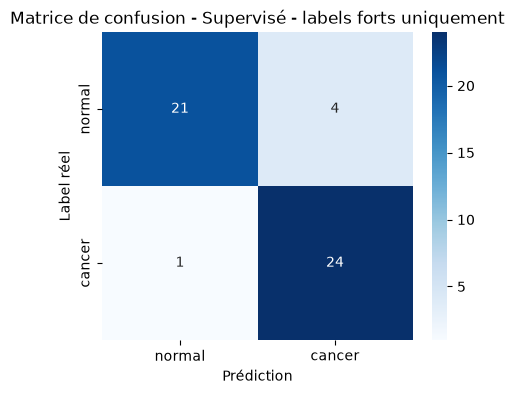

In [46]:
# Modèle baseline supervisé
supervised_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
)

supervised_model.fit(X_train_strong, y_train_strong)

supervised_metrics, supervised_pred = evaluate_model(
    supervised_model,
    X_test,
    y_test,
    "Supervisé - labels forts uniquement"
)

In [47]:
# Refaire KMeans sans le test fort
pseudo_source_df = pd.concat(
    [train_strong_df, unknown_df],
    axis=0
).copy()

X_pseudo_source = pseudo_source_df[feature_columns].values

kmeans_model = make_pipeline(
    StandardScaler(),
    KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
    )
)

pseudo_source_df["cluster_kmeans_modeling"] = kmeans_model.fit_predict(X_pseudo_source)

train_strong_df = pseudo_source_df[pseudo_source_df["label"].isin(["normal", "cancer"])].copy()
unknown_with_clusters_df = pseudo_source_df[pseudo_source_df["label"] == "unknown"].copy()

display(pd.crosstab(
    train_strong_df["cluster_kmeans_modeling"],
    train_strong_df["label"]
))

label,cancer,normal
cluster_kmeans_modeling,,
0,7,24
1,15,1
2,3,0


In [48]:
# Associer chaque cluster KMeans à un label majoritaire
# on associe chaque cluster KMeans à son label majoritaire, en utilisant seulement les labels forts du train.
cluster_label_table = pd.crosstab(
    train_strong_df["cluster_kmeans_modeling"],
    train_strong_df["label"]
)

cluster_to_label = cluster_label_table.idxmax(axis=1).to_dict()

cluster_to_label

{0: 'normal', 1: 'cancer', 2: 'cancer'}

In [49]:
# Pseudo-labelliser uniquement les unknown
unknown_with_clusters_df["pseudo_label"] = (
    unknown_with_clusters_df["cluster_kmeans_modeling"].map(cluster_to_label)
)

pseudo_labeled_df = unknown_with_clusters_df.dropna(subset=["pseudo_label"]).copy()

display(pseudo_labeled_df["pseudo_label"].value_counts())

pseudo_label
cancer    820
normal    586
Name: count, dtype: int64

In [50]:
# Construire le train semi-supervisé avec pondération
train_strong_for_semi = train_strong_df.copy()
train_strong_for_semi["training_label"] = train_strong_for_semi["label"]
train_strong_for_semi["sample_weight"] = 1.0

pseudo_labeled_for_semi = pseudo_labeled_df.copy()
pseudo_labeled_for_semi["training_label"] = pseudo_labeled_for_semi["pseudo_label"]
pseudo_labeled_for_semi["sample_weight"] = 0.2

semi_train_df = pd.concat(
    [train_strong_for_semi, pseudo_labeled_for_semi],
    axis=0
)

X_train_semi = semi_train_df[feature_columns].values
y_train_semi = semi_train_df["training_label"].values
sample_weight_semi = semi_train_df["sample_weight"].values

print("Train supervisé :", len(train_strong_df))
print("Train semi-supervisé :", len(semi_train_df))
display(semi_train_df["training_label"].value_counts())
display(semi_train_df["sample_weight"].value_counts())

Train supervisé : 50
Train semi-supervisé : 1456


training_label
cancer    845
normal    611
Name: count, dtype: int64

sample_weight
0.2    1406
1.0      50
Name: count, dtype: int64

In [51]:
# Vérifier la fuite de données entre le test et le train semi-supervisé (Résultat attendu : 0)
test_paths = set(test_strong_df["path"])
semi_train_paths = set(semi_train_df["path"])

leakage = test_paths.intersection(semi_train_paths)

print("Images du test présentes dans le train semi-supervisé :", len(leakage))

Images du test présentes dans le train semi-supervisé : 0


Semi-supervisé pondéré - labels forts + pseudo-labels
              precision    recall  f1-score   support

      cancer       0.95      0.80      0.87        25
      normal       0.83      0.96      0.89        25

    accuracy                           0.88        50
   macro avg       0.89      0.88      0.88        50
weighted avg       0.89      0.88      0.88        50



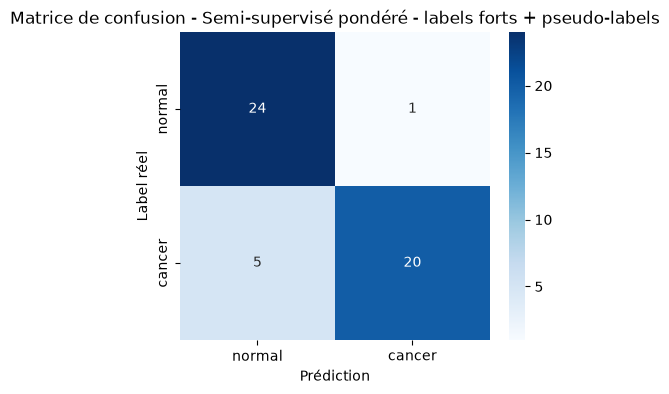

In [52]:
# Entraîner le modèle semi-supervisé pondéré
semi_supervised_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
)

semi_supervised_model.fit(
    X_train_semi,
    y_train_semi,
    logisticregression__sample_weight=sample_weight_semi
)

semi_supervised_metrics, semi_supervised_pred = evaluate_model(
    semi_supervised_model,
    X_test,
    y_test,
    "Semi-supervisé pondéré - labels forts + pseudo-labels"
)

In [53]:
# Comparaison des performances
metrics_df = pd.DataFrame([
    supervised_metrics,
    semi_supervised_metrics
])

display(metrics_df)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_cancer
0,Supervisé - labels forts uniquement,0.90,0.905844,0.90,0.899639,0.905660
1,Semi-supervisé pondéré - labels forts + pseudo...,0.88,0.889984,0.88,0.879227,0.869565


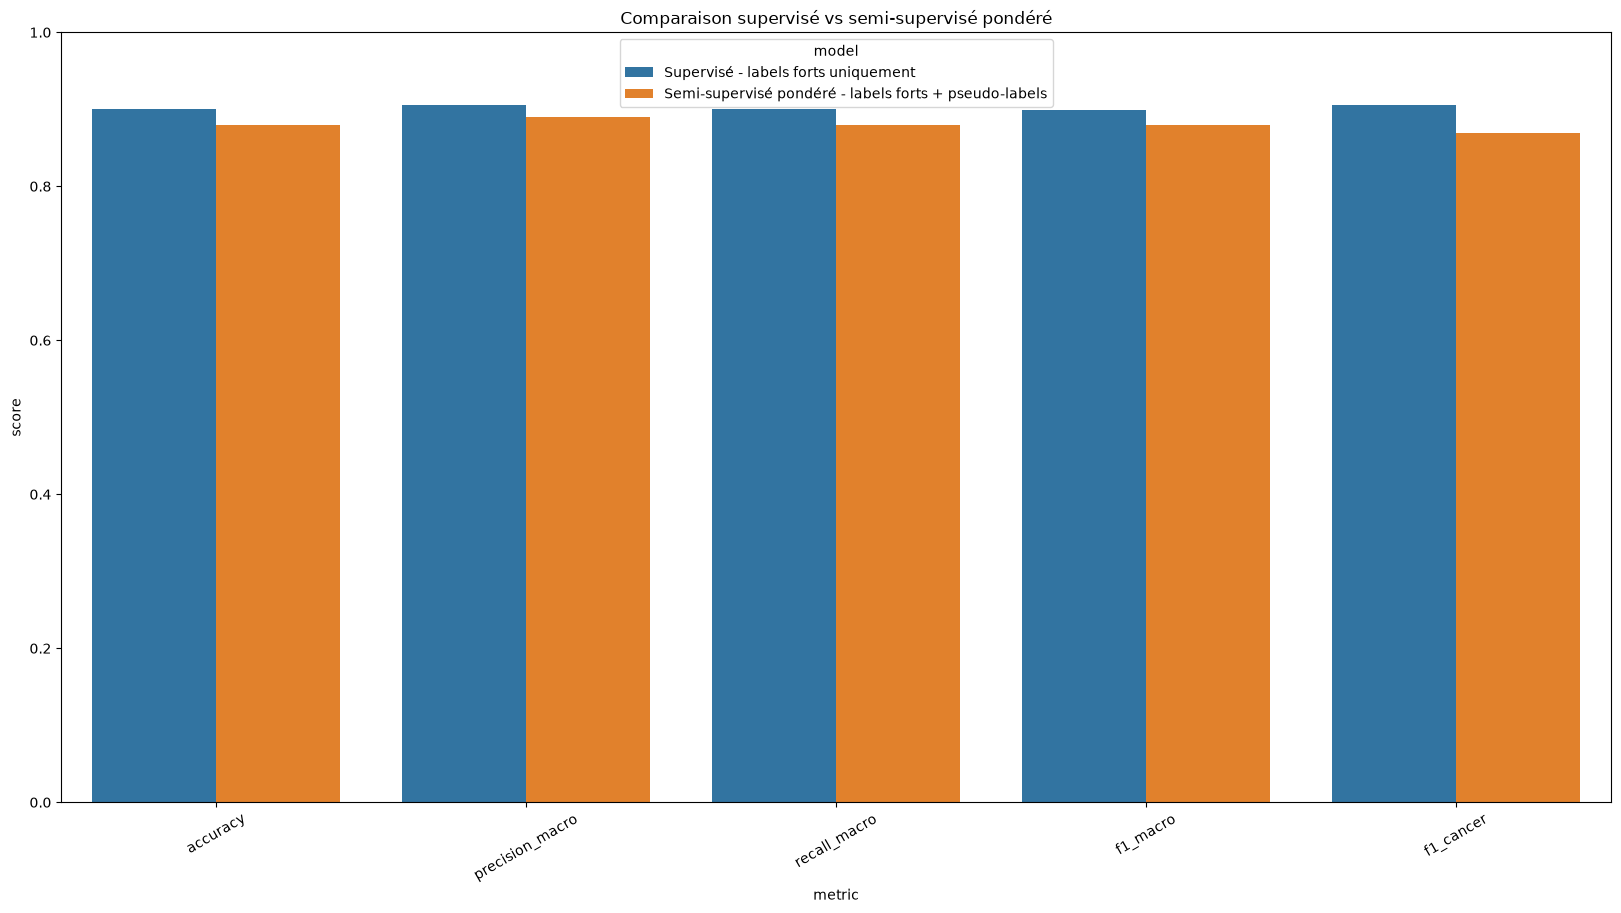

In [54]:
metrics_long = metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_cancer"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(20, 10))
sns.barplot(
    data=metrics_long,
    x="metric",
    y="score",
    hue="model"
)
plt.ylim(0, 1)
plt.title("Comparaison supervisé vs semi-supervisé pondéré")
plt.xticks(rotation=30)
plt.show()

In [56]:
# Comparaison des prédictions
prediction_comparison = test_strong_df[["path", "label"]].copy()
prediction_comparison["supervised_pred"] = supervised_pred
prediction_comparison["semi_supervised_pred"] = semi_supervised_pred
prediction_comparison["same_prediction"] = (
    prediction_comparison["supervised_pred"]
    == prediction_comparison["semi_supervised_pred"]
)

display(prediction_comparison["same_prediction"].value_counts())
display(prediction_comparison)

same_prediction
True     43
False     7
Name: count, dtype: int64

,path,label,supervised_pred,semi_supervised_pred,same_prediction
58,data\raw\avec_labels\normal\2794c549-1ec3-4d08...,normal,normal,normal,True
22,data\raw\avec_labels\cancer\9973120d-7335-43da...,cancer,cancer,cancer,True
7,data\raw\avec_labels\cancer\2d662cc1-509b-4657...,cancer,cancer,cancer,True
63,data\raw\avec_labels\normal\4131a20d-a19d-4cd9...,normal,normal,normal,True
23,data\raw\avec_labels\cancer\9c3a8bbd-8bdb-4fdc...,cancer,cancer,cancer,True
18,data\raw\avec_labels\cancer\7e3f6acd-c9cc-440e...,cancer,normal,normal,True
33,data\raw\avec_labels\cancer\be3210d7-e2d1-4cc3...,cancer,cancer,cancer,True
10,data\raw\avec_labels\cancer\46587a13-4250-4d3e...,cancer,cancer,normal,False
28,data\raw\avec_labels\cancer\ad5ff4c2-0fe6-4e8c...,cancer,cancer,cancer,True
65,data\raw\avec_labels\normal\42ba7707-26c1-42bc...,normal,cancer,normal,False


In [57]:
# Validation croisée supervisée
def supervised_cv(strong_df, feature_columns, n_splits=5):
    X = strong_df[feature_columns].values
    y = strong_df["label"].values

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(X, y), start=1):
        X_train, X_fold_test = X[train_pos], X[test_pos]
        y_train, y_fold_test = y[train_pos], y[test_pos]

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_fold_test)

        results.append({
            "fold": fold,
            "model": "supervised_cv",
            "accuracy": accuracy_score(y_fold_test, y_pred),
            "f1_macro": f1_score(y_fold_test, y_pred, average="macro", zero_division=0),
            "f1_cancer": f1_score(y_fold_test, y_pred, pos_label="cancer", zero_division=0),
        })

    return pd.DataFrame(results)

supervised_cv_df = supervised_cv(strong_df, feature_columns)

display(supervised_cv_df)
display(supervised_cv_df.mean(numeric_only=True))
display(supervised_cv_df.std(numeric_only=True))

,fold,model,accuracy,f1_macro,f1_cancer
0,1,supervised_cv,0.90,0.898990,0.909091
1,2,supervised_cv,0.95,0.949875,0.952381
2,3,supervised_cv,0.95,0.949875,0.947368
3,4,supervised_cv,0.95,0.949875,0.952381
4,5,supervised_cv,0.95,0.949875,0.947368


fold         3.000000
accuracy     0.940000
f1_macro     0.939698
f1_cancer    0.941718
dtype: float64

fold         1.581139
accuracy     0.022361
f1_macro     0.022756
f1_cancer    0.018410
dtype: float64

In [58]:
# Validation croisée semi-supervisée
def semi_supervised_cv(strong_df, unknown_df, feature_columns, n_splits=5, pseudo_weight=0.2, k=3):
    X_strong = strong_df[feature_columns].values
    y_strong = strong_df["label"].values

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    results = []

    for fold, (train_pos, test_pos) in enumerate(skf.split(X_strong, y_strong), start=1):
        train_strong_fold = strong_df.iloc[train_pos].copy()
        test_strong_fold = strong_df.iloc[test_pos].copy()

        pseudo_source_fold = pd.concat(
            [train_strong_fold, unknown_df],
            axis=0
        ).copy()

        X_pseudo_source = pseudo_source_fold[feature_columns].values

        kmeans_fold = make_pipeline(
            StandardScaler(),
            KMeans(
                n_clusters=k,
                random_state=42,
                n_init=10
            )
        )

        pseudo_source_fold["cluster_kmeans_modeling"] = kmeans_fold.fit_predict(X_pseudo_source)

        train_fold_with_clusters = pseudo_source_fold[
            pseudo_source_fold["label"].isin(["normal", "cancer"])
        ].copy()

        unknown_fold_with_clusters = pseudo_source_fold[
            pseudo_source_fold["label"] == "unknown"
        ].copy()

        cluster_label_table = pd.crosstab(
            train_fold_with_clusters["cluster_kmeans_modeling"],
            train_fold_with_clusters["label"]
        )

        cluster_to_label = cluster_label_table.idxmax(axis=1).to_dict()

        unknown_fold_with_clusters["pseudo_label"] = (
            unknown_fold_with_clusters["cluster_kmeans_modeling"].map(cluster_to_label)
        )

        pseudo_labeled_fold = unknown_fold_with_clusters.dropna(subset=["pseudo_label"]).copy()

        train_fold_with_clusters["training_label"] = train_fold_with_clusters["label"]
        train_fold_with_clusters["sample_weight"] = 1.0

        pseudo_labeled_fold["training_label"] = pseudo_labeled_fold["pseudo_label"]
        pseudo_labeled_fold["sample_weight"] = pseudo_weight

        semi_train_fold = pd.concat(
            [train_fold_with_clusters, pseudo_labeled_fold],
            axis=0
        )

        X_train = semi_train_fold[feature_columns].values
        y_train = semi_train_fold["training_label"].values
        sample_weight = semi_train_fold["sample_weight"].values

        X_fold_test = test_strong_fold[feature_columns].values
        y_fold_test = test_strong_fold["label"].values

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )

        model.fit(
            X_train,
            y_train,
            logisticregression__sample_weight=sample_weight
        )

        y_pred = model.predict(X_fold_test)

        results.append({
            "fold": fold,
            "model": "semi_supervised_cv",
            "accuracy": accuracy_score(y_fold_test, y_pred),
            "f1_macro": f1_score(y_fold_test, y_pred, average="macro", zero_division=0),
            "f1_cancer": f1_score(y_fold_test, y_pred, pos_label="cancer", zero_division=0),
            "pseudo_weight": pseudo_weight,
            "n_train": len(semi_train_fold),
        })

    return pd.DataFrame(results)

semi_supervised_cv_df = semi_supervised_cv(
    strong_df,
    unknown_df,
    feature_columns,
    pseudo_weight=0.2,
    k=3
)

display(semi_supervised_cv_df)
display(semi_supervised_cv_df.mean(numeric_only=True))
display(semi_supervised_cv_df.std(numeric_only=True))

,fold,model,accuracy,f1_macro,f1_cancer,pseudo_weight,n_train
0,1,semi_supervised_cv,0.85,0.849624,0.842105,0.2,1486
1,2,semi_supervised_cv,0.90,0.900000,0.900000,0.2,1486
2,3,semi_supervised_cv,0.95,0.949875,0.947368,0.2,1486
3,4,semi_supervised_cv,0.75,0.744246,0.705882,0.2,1486
4,5,semi_supervised_cv,0.85,0.846547,0.823529,0.2,1486


fold                3.000000
accuracy            0.860000
f1_macro            0.858058
f1_cancer           0.843777
pseudo_weight       0.200000
n_train          1486.000000
dtype: float64

fold             1.581139
accuracy         0.074162
f1_macro         0.076398
f1_cancer        0.091269
pseudo_weight    0.000000
n_train          0.000000
dtype: float64

In [59]:
# Comparaison CV
cv_results_df = pd.concat(
    [supervised_cv_df, semi_supervised_cv_df],
    axis=0
)

display(cv_results_df)

cv_summary = cv_results_df.groupby("model")[["accuracy", "f1_macro", "f1_cancer"]].agg(["mean", "std"])

display(cv_summary)

,fold,model,accuracy,f1_macro,f1_cancer,pseudo_weight,n_train
0,1,supervised_cv,0.90,0.898990,0.909091,NaN,NaN
1,2,supervised_cv,0.95,0.949875,0.952381,NaN,NaN
2,3,supervised_cv,0.95,0.949875,0.947368,NaN,NaN
3,4,supervised_cv,0.95,0.949875,0.952381,NaN,NaN
4,5,supervised_cv,0.95,0.949875,0.947368,NaN,NaN
0,1,semi_supervised_cv,0.85,0.849624,0.842105,0.2,1486.0
1,2,semi_supervised_cv,0.90,0.900000,0.900000,0.2,1486.0
2,3,semi_supervised_cv,0.95,0.949875,0.947368,0.2,1486.0
3,4,semi_supervised_cv,0.75,0.744246,0.705882,0.2,1486.0
4,5,semi_supervised_cv,0.85,0.846547,0.823529,0.2,1486.0


accuracy            f1_macro           f1_cancer          
                       mean       std      mean       std      mean       std
model                                                                        
semi_supervised_cv     0.86  0.074162  0.858058  0.076398  0.843777  0.091269
supervised_cv          0.94  0.022361  0.939698  0.022756  0.941718  0.018410

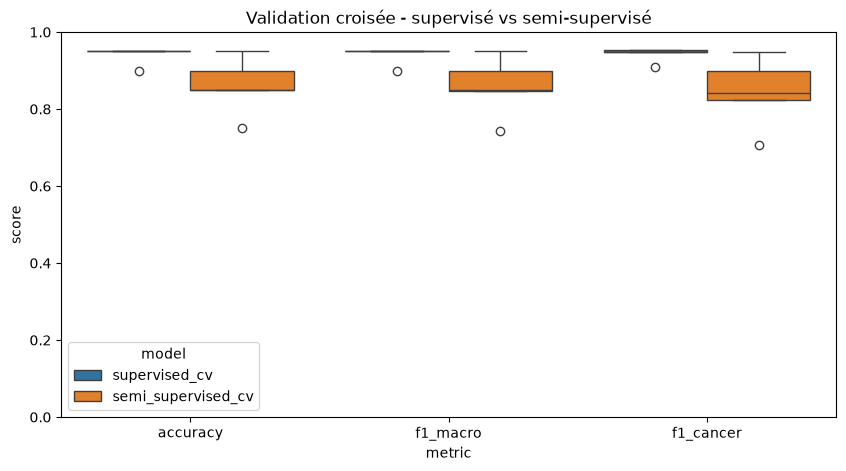

In [60]:
cv_plot_df = cv_results_df.melt(
    id_vars=["fold", "model"],
    value_vars=["accuracy", "f1_macro", "f1_cancer"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=cv_plot_df,
    x="metric",
    y="score",
    hue="model"
)
plt.ylim(0, 1)
plt.title("Validation croisée - supervisé vs semi-supervisé")
plt.show()

La pseudo-labellisation augmente fortement la taille du jeu d'entraînement, de 70 images fortement labellisées à 1476 images au total. Cependant, les performances restent proches entre les deux modèles.

Cela suggère que les embeddings ResNet sont déjà fortement discriminants avec peu de labels, et que les pseudo-labels KMeans ajoutent surtout des exemples cohérents avec la frontière déjà apprise. Le gain mesurable reste limité, probablement aussi à cause de la petite taille du jeu de test.

In [61]:
# Sauvegarde
OUTPUT_DIR = Path("data/processed")

metrics_path = OUTPUT_DIR / "modeling_metrics_50_50.csv"
cv_results_path = OUTPUT_DIR / "modeling_cv_results.csv"
pseudo_labels_path = OUTPUT_DIR / "pseudo_labels_kmeans_modeling.csv"
semi_train_path = OUTPUT_DIR / "semi_supervised_training_set_50_50.csv"

metrics_df.to_csv(metrics_path, index=False)
cv_results_df.to_csv(cv_results_path, index=False)
pseudo_labeled_df.to_csv(pseudo_labels_path, index=False)
semi_train_df.to_csv(semi_train_path, index=False)

print("Métriques split 50/50 :", metrics_path)
print("Résultats CV :", cv_results_path)
print("Pseudo-labels :", pseudo_labels_path)
print("Train semi-supervisé :", semi_train_path)

Métriques split 50/50 : data\processed\modeling_metrics_50_50.csv
Résultats CV : data\processed\modeling_cv_results.csv
Pseudo-labels : data\processed\pseudo_labels_kmeans_modeling.csv
Train semi-supervisé : data\processed\semi_supervised_training_set_50_50.csv


## Interprétation

Le modèle supervisé est entraîné uniquement sur les images fortement labellisées présentes dans le train.

Le modèle semi-supervisé utilise les mêmes images fortement labellisées, auxquelles on ajoute les images initialement non labellisées. Ces images reçoivent un pseudo-label déterminé à partir du label majoritaire du cluster KMeans.

Les labels réels `normal` et `cancer` restent prioritaires : lorsqu'une image possède un label fort, ce label est utilisé et n'est jamais remplacé par un pseudo-label.

Le jeu de test est composé uniquement d'images fortement labellisées et n'est jamais utilisé pour créer les pseudo-labels. Cela limite le risque de fuite de données.

La métrique prioritaire est le F1-score de la classe `cancer`, car manquer une image cancéreuse est l'erreur la plus critique. Le F1 macro est également suivi pour évaluer l'équilibre global entre les classes.

In [ ]:
# Sauvegarder les métriques et les pseudo-labels
OUTPUT_DIR = Path("data/processed")

metrics_path = OUTPUT_DIR / "modeling_metrics_50_50.csv"
cv_results_path = OUTPUT_DIR / "modeling_cv_results.csv"
pseudo_labels_path = OUTPUT_DIR / "pseudo_labels_kmeans_modeling.csv"
semi_train_path = OUTPUT_DIR / "semi_supervised_training_set_50_50.csv"

metrics_df.to_csv(metrics_path, index=False)
cv_results_df.to_csv(cv_results_path, index=False)
pseudo_labeled_df.to_csv(pseudo_labels_path, index=False)
semi_train_df.to_csv(semi_train_path, index=False)

print("Métriques split 50/50 :", metrics_path)
print("Résultats CV :", cv_results_path)
print("Pseudo-labels :", pseudo_labels_path)
print("Train semi-supervisé :", semi_train_path)

Métriques sauvegardées : data\processed\modeling_metrics.csv
Pseudo-labels sauvegardés : data\processed\pseudo_labels_kmeans.csv
Jeu d'entraînement semi-supervisé sauvegardé : data\processed\semi_supervised_training_set.csv


## Definition of Done - Étape 4

L'étape 4 est considérée comme terminée si :

- un split train/test stratifié est créé sur les données fortement labellisées ;
- le jeu de test n'est jamais utilisé pour générer les pseudo-labels ;
- un modèle supervisé est entraîné uniquement sur les labels forts ;
- les pseudo-labels sont générés uniquement pour les images `unknown` ;
- les labels forts ne sont jamais remplacés par des pseudo-labels ;
- un modèle semi-supervisé est entraîné sur labels forts + pseudo-labels ;
- les deux modèles sont évalués sur le même jeu de test ;
- les métriques accuracy, precision, recall et F1-score sont comparées ;
- la classe `cancer` est analysée en priorité ;
- les résultats sont sauvegardés.